In [26]:
import pandas as pd 
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller # тест дики-фуллера
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # графики параметров
from statsmodels.tsa.arima.model import ARIMA # базовая модель аримы
from statsmodels.tsa.statespace.sarimax import SARIMAX # модель с сезонностью
from statsmodels.tsa.seasonal import seasonal_decompose 
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error 
import pmdarima as pm # авто-подбор параметров
import statsmodels.api as sm # для теста льюнга-бокса

## Подготовка и анализ

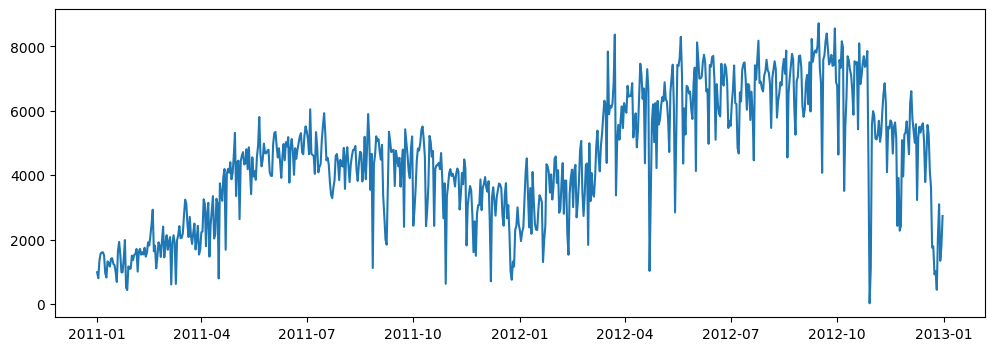

p-value до: 0.3427
p-value после: 0.0000


In [20]:
df = pd.read_csv('../data/day.csv') 
df['dteday'] = pd.to_datetime(df['dteday']) # переводим в формат даты
df.set_index('dteday', inplace=True) # делаем дату индексом

plt.figure(figsize=(12, 4)) 
plt.plot(df['cnt']) 
plt.show() 

p_val = adfuller(df['cnt'].dropna())[1] # проверяем на стационарность
print(f'p-value до: {p_val:.4f}') # больше 0.05 - есть тренд, ряд нестационарен

df['diff'] = df['cnt'].diff() # берем первую разность (вычитаем вчера из сегодня)
p_val_diff = adfuller(df['diff'].dropna())[1] # снова проверяем
print(f'p-value после: {p_val_diff:.4f}') # теперь меньше 0.05, ряд стабилизирован, значит d=1

## Базовая ARIMA-модель

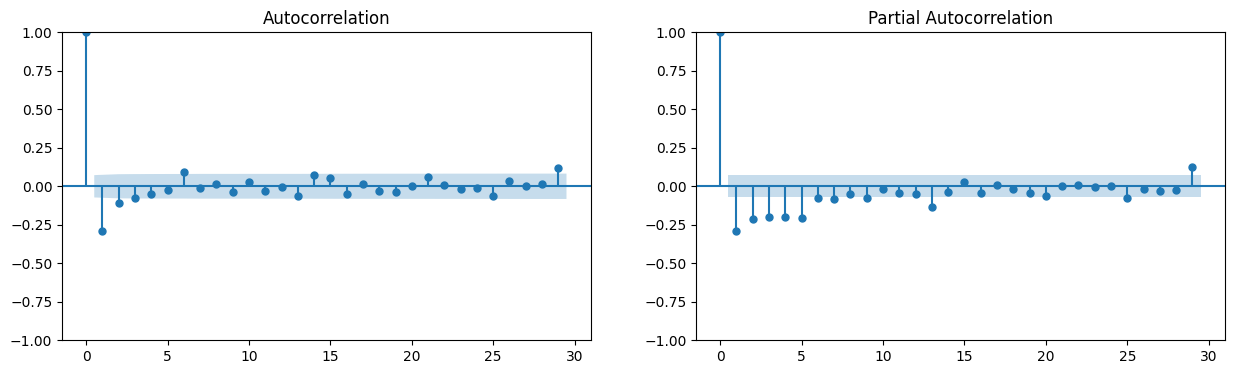

ARIMA RMSE: 2936.07, MAPE: 5.35


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4)) 
plot_acf(df['diff'].dropna(), ax=axes[0]) # смотрим параметр q 
plot_pacf(df['diff'].dropna(), ax=axes[1]) # смотрим параметр p 
plt.show() # показываем графики преподу

train_size = int(len(df) * 0.9) # берем 90% данных на обучение
train, test = df.iloc[:train_size], df.iloc[train_size:] # делим датасет

model = ARIMA(train['cnt'], order=(1, 1, 1)) # создаем модель (d=1 так как брали 1 разность)
fit_model = model.fit() # запускаем обучение

preds = fit_model.forecast(steps=len(test)) # предсказываем на длину тестовой выборки
rmse = root_mean_squared_error(test['cnt'], preds) # считаем среднеквадратичную ошибку
mape = mean_absolute_percentage_error(test['cnt'], preds) # считаем ошибку в процентах
print(f'ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2f}') 

## Диагностика модели

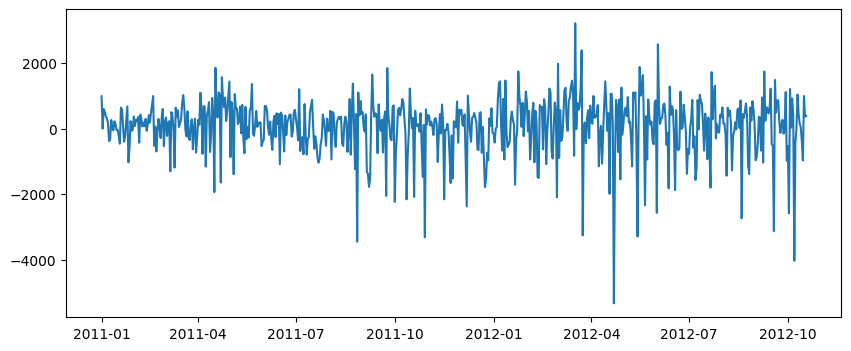

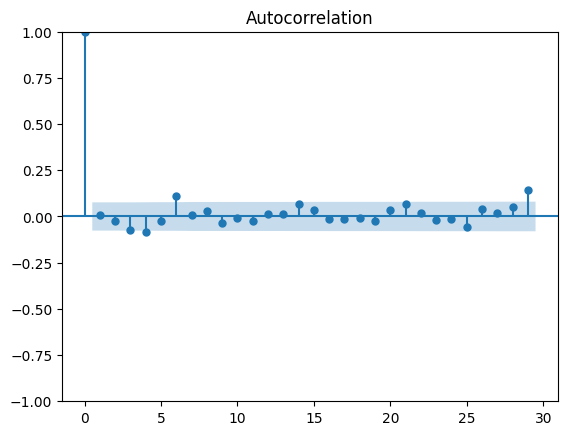

      lb_stat  lb_pvalue
10  18.441833   0.047952


In [22]:
residuals = fit_model.resid # достаем ошибки модели на обучающей выборке
plt.figure(figsize=(10, 4)) 
plt.plot(residuals) # остатки должны быть похожи на белый хаотичный шум вокруг нуля
plt.show()

plot_acf(residuals.dropna()) # проверяем, есть ли зависимости внутри остатков
plt.show() 

lb_test = sm.stats.acorr_ljungbox(residuals.dropna(), lags=[10]) # тест льюнга-бокса
print(lb_test) # если lb_pvalue больше 0.05, значит остатки случайны

## Сезонная модель SARIMA

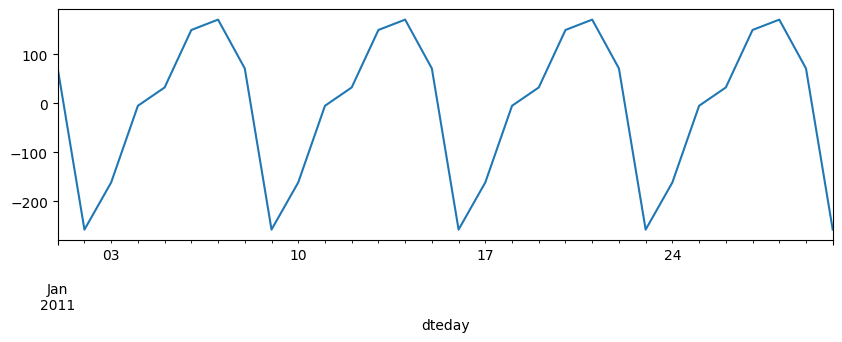

SARIMA MAPE: 5.27


In [23]:
decomp = seasonal_decompose(df['cnt'].dropna(), period=7) # ищем недельную сезонность (7 дней)
decomp.seasonal[:30].plot(figsize=(10, 3)) # рисуем кусочек (первый месяц) чтобы было наглядно
plt.show() # препод увидит четкие волны - спад на выходных, это и есть сезонность

sarima = SARIMAX(train['cnt'], order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)) # добавляем сезонные параметры
fit_sarima = sarima.fit(disp=False) # обучаем (disp=False прячет лишний текст)

preds_sarima = fit_sarima.forecast(steps=len(test)) # делаем прогноз
mape_sarima = mean_absolute_percentage_error(test['cnt'], predчs_sarima) # считаем метрику
print(f'SARIMA MAPE: {mape_sarima:.2f}') # ошибка стала меньше, так как учли дни недели

## SARIMAX и внешние факторы (Погода)

In [24]:
exog_train = train[['temp']] # фактор для обучения - температура (чем теплее, тем больше аренд)
exog_test = test[['temp']] # тот же фактор для теста

sarimax = SARIMAX(train['cnt'], exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)) # передаем exog
fit_sarimax = sarimax.fit(disp=False) # обучаем с учетом погоды

preds_sarimax = fit_sarimax.forecast(steps=len(test), exog=exog_test) # прогнозируем вместе с погодой
mape_sarimax = mean_absolute_percentage_error(test['cnt'], preds_sarimax) # считаем метрику
print(f'SARIMAX MAPE: {mape_sarimax:.2f}')

print(fit_sarimax.summary().tables[1]) # P>|z| у строки temp (если < 0.05, фактор сильно влияет)

SARIMAX MAPE: 4.92
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        4644.5731    463.435     10.022      0.000    3736.257    5552.889
ar.L1          0.3072      0.038      8.021      0.000       0.232       0.382
ma.L1         -0.9250      0.016    -56.552      0.000      -0.957      -0.893
ar.S.L7        0.9996      0.012     85.768      0.000       0.977       1.022
ma.S.L7       -0.9968      0.050    -19.873      0.000      -1.095      -0.898
sigma2       6.88e+05      1.098   6.26e+05      0.000    6.88e+05    6.88e+05


## Автоматизация подбора (auto-ARIMA)

In [25]:
auto_model = pm.auto_arima(train['cnt'], X=exog_train, seasonal=True, m=7, trace=True) # сам перебирает параметры
print(auto_model.summary()) # смотрим итоговый отчет и какие (p,d,q) в итоге выбрала машина

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=10700.180, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=10920.608, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=10849.716, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=10744.981, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=10918.670, Time=0.04 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=10702.179, Time=1.22 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=10702.197, Time=1.30 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=inf, Time=1.17 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=10705.279, Time=1.43 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=10699.612, Time=0.71 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=10697.4

# Ответы на вопросы

### 1.  Алгоритм ошибается, когда в данных происходят резкие непредсказуемые скачки (например, кризис или пандемия) или если у ряда есть сложная двойная сезонность (зависит и от дня недели, и от месяца одновременно). Так как алгоритм опирается только на сухую математику, он может принять случайную аномалию за строгую закономерность и подобрать неверные параметры

### 2. Чаще всего алгоритм завышает параметры разности (d и D). Он старается максимально "выровнять" ряд, беря лишнюю разность. Это плохо, потому что с каждым таким действием модель безвозвратно теряет часть полезной информации о реальном тренде, что делает прогноз менее надежным

### 3. Полностью вслепую доверять нельзя. В реальном мире данные постоянно меняются (меняется экономика, поведение людей). Если оставить auto-ARIMA работать полностью автономно, в какой-то момент она может перестроиться на неправильные параметры и сломать бизнес-логику. Поэтому на сервере за моделью всегда должен стоять мониторинг: если ошибка начала расти, нужно вмешаться и проверить всё руками